In [15]:
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report

In [16]:
# Load dataset
df = pd.read_csv("C:/Users/gdani/OneDrive/Desktop/master thesis/processed_model01_dataset.csv", delimiter=";")
# Define numerical and categorical columns
numerical_cols = ['duration', 'credit_amount', 'installment_rate', 'residence_duration', 'age', 'number_of_credits', 'people_liable']
categorical_cols = ['status', 'credit_history', 'purpose', 'savings/bonds', 'employment_duration', 'personal_status_and_sex',
                    'other_debtors', 'property', 'installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
# Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols)
#this simply reorder the columns of the df making sure that 'credit_risck' and 'predicted_lable' are last
final_columns = numerical_cols + [col for col in df_encoded.columns if col not in numerical_cols + ['credit_risk', 'predicted_label']] + ['credit_risk', 'predicted_label']
df_encoded = df_encoded[final_columns]
df_encoded.columns



Index(['duration', 'credit_amount', 'installment_rate', 'residence_duration',
       'age', 'number_of_credits', 'people_liable', 'id', 'status_1.0',
       'status_2.0', 'status_3.0', 'status_4.0', 'credit_history_0.0',
       'credit_history_1.0', 'credit_history_2.0', 'credit_history_3.0',
       'credit_history_4.0', 'purpose_0.0', 'purpose_1.0', 'purpose_2.0',
       'purpose_3.0', 'purpose_4.0', 'purpose_5.0', 'purpose_6.0',
       'purpose_8.0', 'purpose_9.0', 'purpose_10.0', 'savings/bonds_1.0',
       'savings/bonds_2.0', 'savings/bonds_3.0', 'savings/bonds_4.0',
       'savings/bonds_5.0', 'employment_duration_1.0',
       'employment_duration_2.0', 'employment_duration_3.0',
       'employment_duration_4.0', 'employment_duration_5.0',
       'personal_status_and_sex_1.0', 'personal_status_and_sex_2.0',
       'personal_status_and_sex_3.0', 'personal_status_and_sex_4.0',
       'other_debtors_1.0', 'other_debtors_2.0', 'other_debtors_3.0',
       'property_1.0', 'property_2.0

In [17]:
df_encoded = df_encoded.dropna()
X = df_encoded.drop(columns=['credit_risk','id', 'predicted_label'])  # Features
y_pred = df_encoded['predicted_label']  # Model's given predictions
df_encoded.to_csv("df_encoded.csv")
X

,duration,credit_amount,installment_rate,residence_duration,age,number_of_credits,people_liable,status_1.0,status_2.0,status_3.0,...,housing_2.0,housing_3.0,job_1.0,job_2.0,job_3.0,job_4.0,telephone_1.0,telephone_2.0,foreign_worker_1.0,foreign_worker_2.0
0,48.0,5951.0,2.0,2.0,22.0,1.0,1.0,False,True,False,...,True,False,False,False,True,False,True,False,True,False
1,12.0,2096.0,2.0,3.0,49.0,1.0,2.0,False,False,False,...,True,False,False,True,False,False,True,False,True,False
2,24.0,2835.0,3.0,4.0,53.0,1.0,1.0,False,False,False,...,True,False,False,False,True,False,True,False,True,False
3,48.0,4308.0,3.0,4.0,24.0,1.0,1.0,True,False,False,...,False,False,False,False,True,False,True,False,True,False
4,24.0,1199.0,4.0,4.0,60.0,2.0,1.0,True,False,False,...,True,False,False,True,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,24.0,6579.0,4.0,2.0,29.0,1.0,1.0,True,False,False,...,False,True,False,False,False,True,False,True,True,False
296,18.0,1936.0,2.0,4.0,23.0,2.0,1.0,True,False,False,...,False,False,False,True,False,False,True,False,True,False
297,36.0,3959.0,4.0,3.0,30.0,1.0,1.0,True,False,False,...,True,False,False,False,False,True,False,True,True,False
298,30.0,3857.0,4.0,4.0,40.0,1.0,1.0,True,False,False,...,True,False,False,False,False,True,False,True,True,False


In [18]:
X_shap = X.copy()

In [19]:
# Initialize XGBoost classifier
model = xgb.XGBClassifier(
    objective="binary:logistic",  # For binary classification
    eval_metric="logloss",  # Avoids warnings
    use_label_encoder=False,
    n_estimators=100,  # Number of boosting rounds
    learning_rate=0.1,
    max_depth=6
)

# Train model
model.fit(X_shap, y_pred)


c:\Users\gdani\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:57:10] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

                    Feature  Importance
10               status_4.0    0.104333
7                status_1.0    0.088000
26        savings/bonds_1.0    0.083000
0                  duration    0.082333
15       credit_history_4.0    0.022333
47    installment_plans_1.0    0.014667
30        savings/bonds_5.0    0.010000
1             credit_amount    0.008667
35  employment_duration_5.0    0.007000
8                status_2.0    0.007000


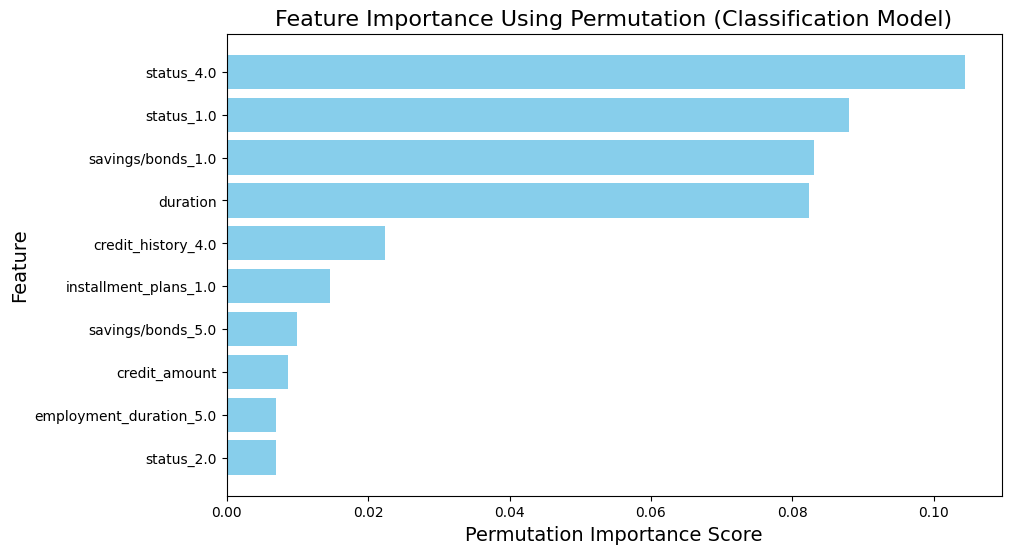

In [20]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Compute permutation importance using classification scoring
perm_importance = permutation_importance(
    model,  
    X_shap,
    y_pred,
    scoring="accuracy",  # Use accuracy for binary classification
    n_repeats=10,  # Number of random shuffles
    random_state=42
)

# Convert results into a DataFrame
importance_df = pd.DataFrame({
    "Feature": X_shap.columns,
    "Importance": perm_importance.importances_mean
}).sort_values(by="Importance", ascending=False)

#Print Feature Importance Rankings
print(importance_df.head(10))

#Plot Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"].head(10), importance_df["Importance"].head(10), color="skyblue")
plt.xlabel("Permutation Importance Score", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.title("Feature Importance Using Permutation (Classification Model)", fontsize=16)
plt.gca().invert_yaxis()  # Highest importance at the top
plt.show()

In [21]:
y = model.predict(X_shap)


In [22]:
# Accuracy Score
accuracy = accuracy_score(y_pred,y)
print(f"Accuracy: {accuracy:.4f}")

# Classification Report
print(classification_report(y_pred,y))


Accuracy: 1.0000
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00       222
         1.0       1.00      1.00      1.00        78

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



<Figure size 5000x600 with 0 Axes>

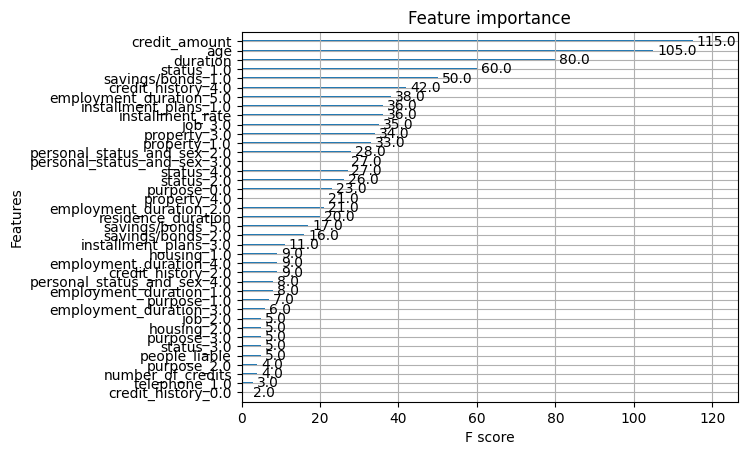

In [23]:
import matplotlib.pyplot as plt
plt.figure(figsize=(50, 6))
xgb.plot_importance(model)
plt.show()


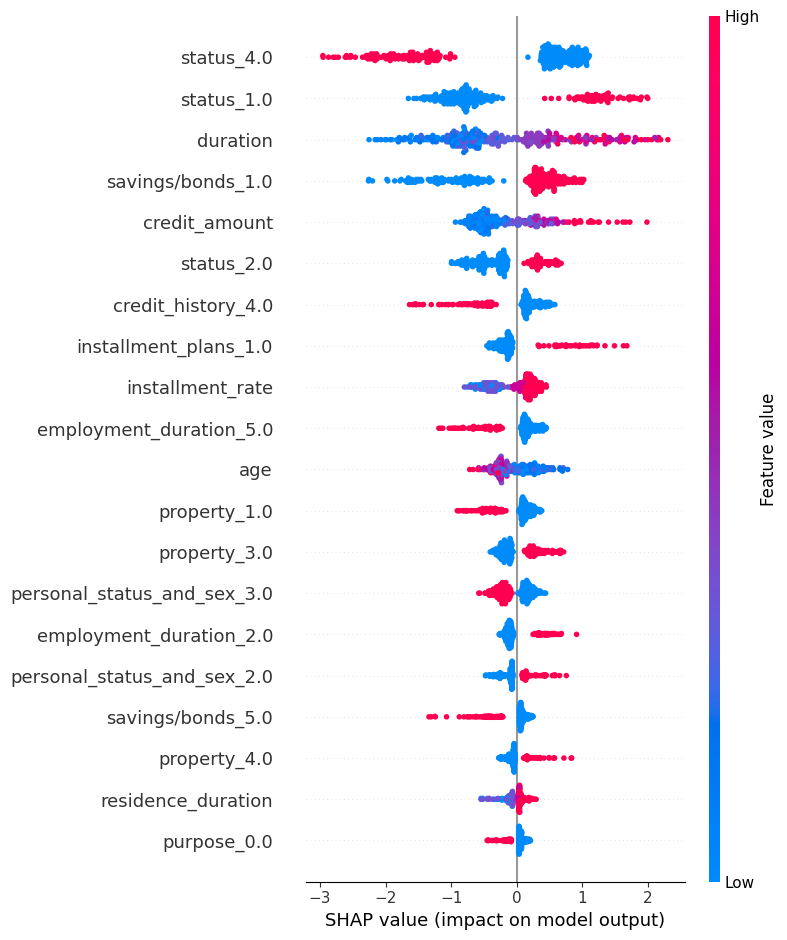

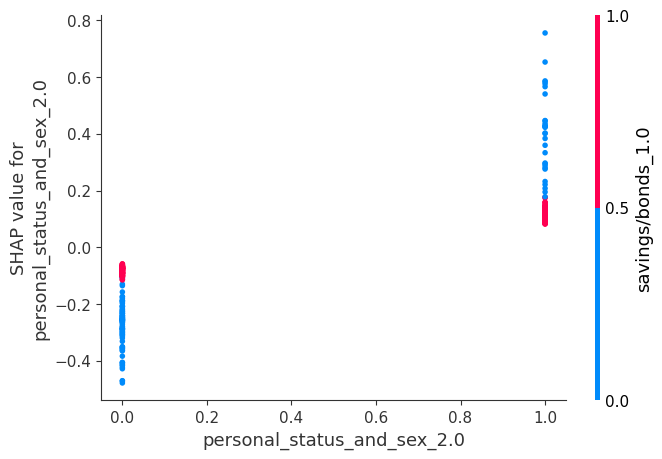

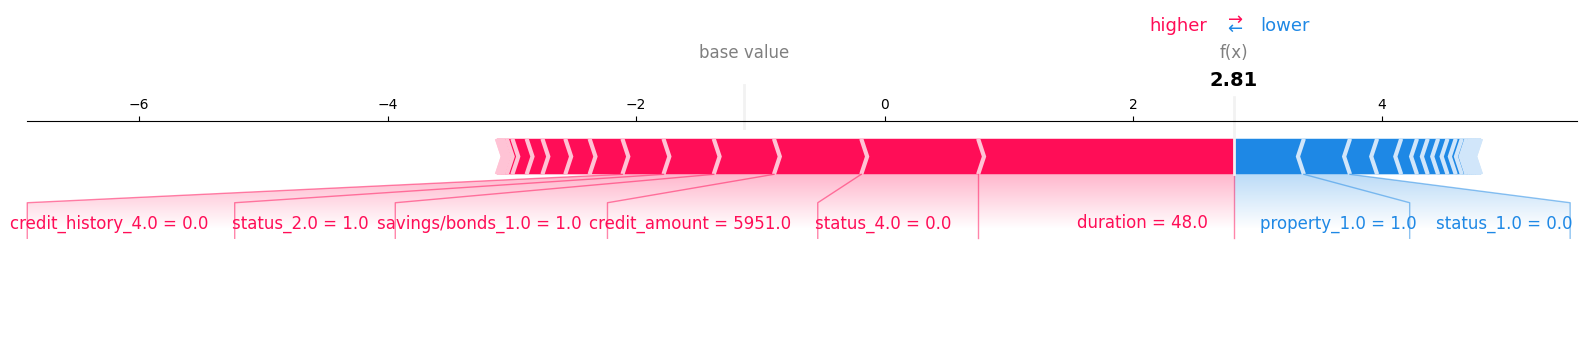

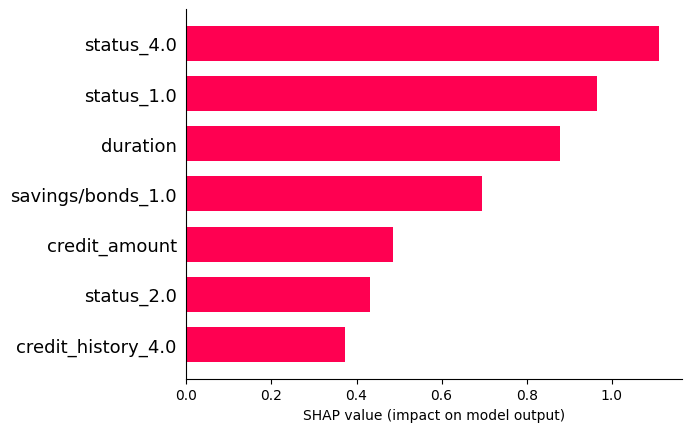

In [24]:
# SHAP Analysis
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap)

# Summary Plot
shap.summary_plot(shap_values, X_shap, feature_names=X_shap.columns)

# Dependence Plot (for specific feature)
shap.dependence_plot("personal_status_and_sex_2.0", shap_values, X_shap)  # Replace "your_feature"

# Force Plot (for a single prediction)
shap.initjs()  # Initialize JavaScript for plots
shap.force_plot(explainer.expected_value, shap_values[0,:], X_shap.iloc[0,:], matplotlib=True)

# Feature Importance Bar Plot
#shap.bar_plot(shap_values, feature_names=X_shap.columns)
import numpy as np

# Get mean absolute SHAP values per feature
shap_importance = np.abs(shap_values).mean(axis=0)

# Plot feature importance
shap.bar_plot(shap_importance, feature_names=X_shap.columns)


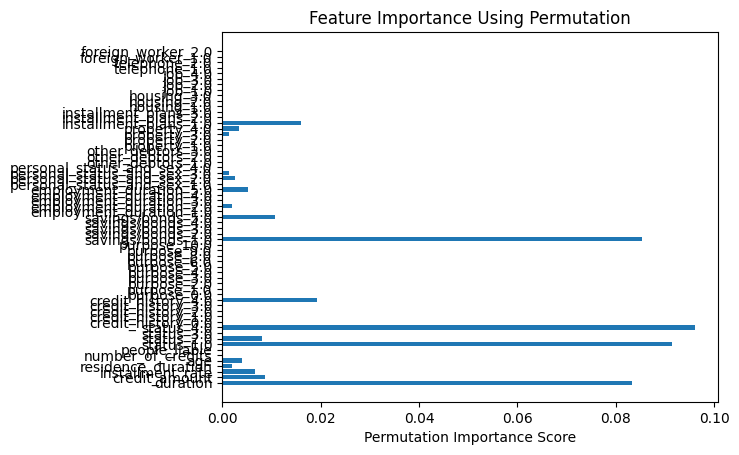

In [25]:
from sklearn.inspection import permutation_importance
perm_importance = permutation_importance(model, X_shap, y, scoring='accuracy', random_state=42)
plt.barh(X_shap.columns, perm_importance.importances_mean)
plt.xlabel("Permutation Importance Score")
plt.title("Feature Importance Using Permutation")
plt.show()


In [26]:
df2 = df_encoded.drop(columns=["id"])
#define feature groups
protected_vars = ["age"] + [col for col in df2.columns if "personal_status_and_sex" in col or "foreign_worker" in col or "job" in col]
economic_vars = ["credit_amount", "installment_rate"] + [col for col in df2.columns if "employment_duration" in col or "savings/bonds" in col]
housing_vars = ["housing_1.0", "housing_2.0", "housing_3.0", "residence_duration", "people_liable"] + [col for col in df2.columns if "property" in col]
all_features = list(set(df2.columns) - set(["credit_risk", "predicted_label"]))

In [27]:
import xgboost

In [28]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 300 entries, 0 to 299
Data columns (total 61 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     300 non-null    float64
 1   credit_amount                300 non-null    float64
 2   installment_rate             300 non-null    float64
 3   residence_duration           300 non-null    float64
 4   age                          300 non-null    float64
 5   number_of_credits            300 non-null    float64
 6   people_liable                300 non-null    float64
 7   status_1.0                   300 non-null    bool   
 8   status_2.0                   300 non-null    bool   
 9   status_3.0                   300 non-null    bool   
 10  status_4.0                   300 non-null    bool   
 11  credit_history_0.0           300 non-null    bool   
 12  credit_history_1.0           300 non-null    bool   
 13  credit_history_2.0       

In [29]:
bool_cols = X.select_dtypes(include=["bool"]).columns
X[bool_cols] = X[bool_cols].astype(int)

In [30]:
model = xgboost.XGBClassifier(
    use_label_encoder=False,  # stops older label-encoder warnings
    eval_metric="logloss"     # recommended evaluation metric for classification
)
model.fit(X, y_pred)

c:\Users\gdani\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:57:33] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=None, ...)

In [31]:
# Create a TreeExplainer automatically
explainer = shap.Explainer(model, X)

# Compute SHAP values for each row in X
shap_values = explainer(X)  # returns a shap.Explanation object

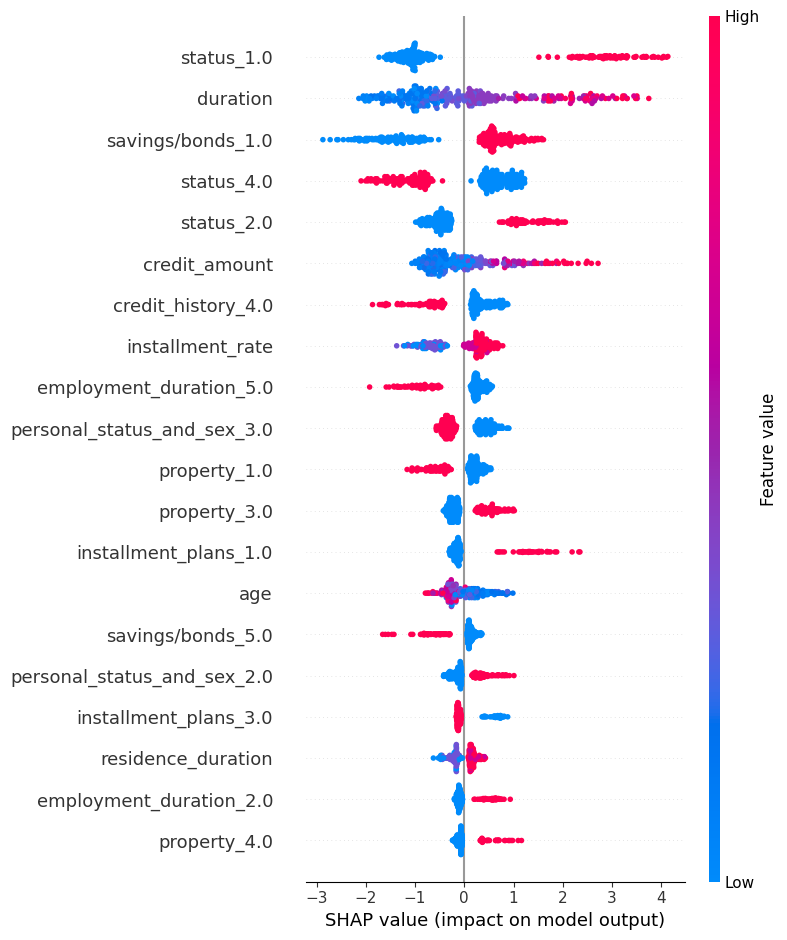

In [32]:
# A) Summary (beeswarm) Plot: each dot is a sample-feature
shap.summary_plot(shap_values, X)

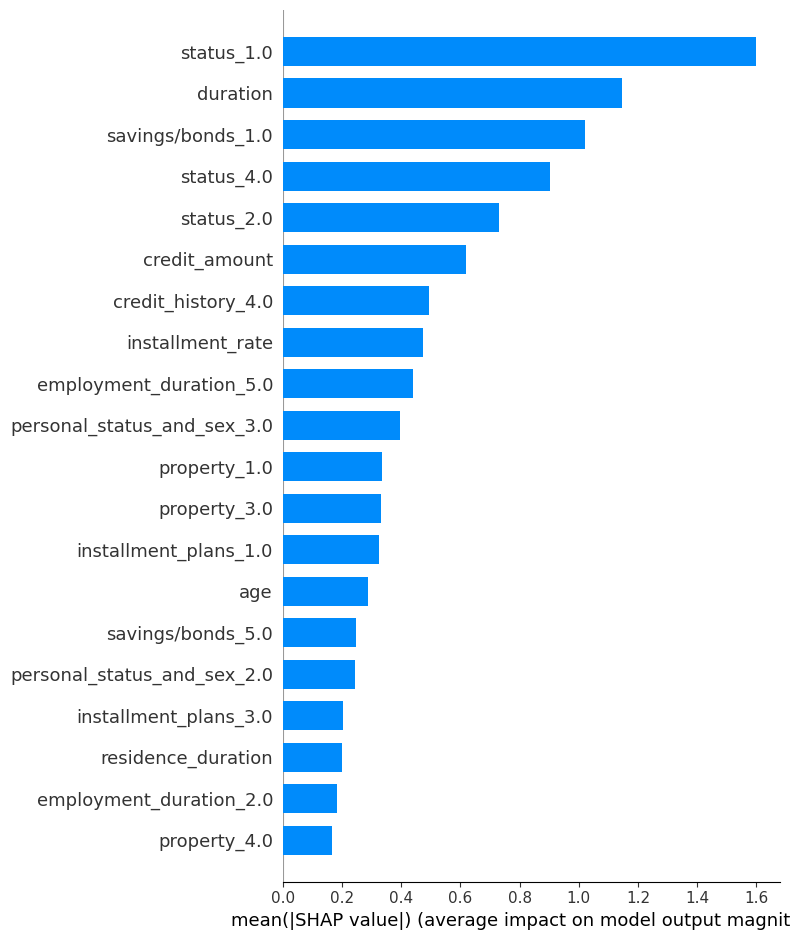

In [33]:
# Summary Bar Plot: average absolute impact per feature
shap.summary_plot(shap_values, X, plot_type="bar")

In [34]:
######